## Selection Addresses 
- cost --> hard to get certain kinds of data, getting some of the features that can be engineered
- speed --> its takes a long time to run models that have extensive observations 
- simplicity --> if there are lots of featues, how do you explain that to someone --> feature selection, expand the features and then contract the features, 
- robustness --> should be a mix of both engineered and original features, less massive features that are hard to recognize for model performance 

## Automatic feature generation 
- feature engine --> don't use if its transforming the ways you don't like
- polynomial featues 
    - interactions --> think about how categorical variables have been encoded, be able to explain what is generated, nonlinear transformations
    - feature encoding multiplied by one another 
    - feature tools: multi table, DFS = deep feature selection

## Filter methods 
- statistical analysis --> are there two features that are very similar and almost the same 
- no modeling
- fast
- hard to see feature interactions 
- don't reflect model behavior 
- tell about individual features

## Wrapper methods 
- RFECV: recursive feature elimination cross validation --> be fair with how you handle the full set of the features, computationaly expensive, unstable with correlated features = miss interactions, unstable with correlated features 
- Forwards selection --> start with no features, add 1 by 1 = miss interactions, unstable with correlated features 
- stepwise selection --> you add and remove features, unstable with correlated features 
- dependent on what hyperparameters to use 

## Embedded methods 
- inside the models
- linear models: smaller weights 
- tree-based models: feature is barely used L1/L2 regularization penalized is used here
- incorporated into model training, a whole new set of steps implemented here 
- what models you use can be biased 
- start with filter methods --> statistical analysis --> look at features and see which ones can be eliminated 
- leverage what the model is doing to give you back the useful information
- you still need to do feature selection

## Classification metrics 
- start using balanced accuracy instead of regular accuracy for the homework to move up on the leaderboard 

## LASSO/Ridge
Feature - importance 
- tied to model selection

permutation - importance --> take the model you already built, shuffles the column values, takes already trained model to make predictions
- issue: you can get a lucky shuffle --> do 10 shuffles 
- ranks each feature on which has the biggest impact when trained 
- tied to model performance 
- you can use for non-tree based models too
- not the best if you have redundant features (correlated features)

Together each are really good, use them paired to get better insight, which was useful for splits 

## Shap
prediction = baseline + feature contributions
- start at the average (baseline) --> look at how model made those predictions 
- look at observation by observation, average across all the observations and look at what impact each feature has 
- takes up lots of computing power
- tree: TreeSHAP
- tell us how predictions were made, how important were these specific features 
- Shap values tell you which features were making a difference to baseline
- bee-swarm plots
- waterfall plots (represents a detailed look of the confusion report)

## Stacking 
Blending/stacking
- averaging of predictions from multiple models (or weighted average)
- meta-learner created using outputs from multiple models 
- use out of fold 
    - Data --> folds --> train on other folds --> predict for that fold --> combine for all trained data --> out of fold predictions * RF, *XGB, * XGB (minority)
    - train meta learner --> RF Regression 
    - retrain the RF/XGB on all the data --> predictions on test 
    


In [35]:
pip install feature-engine


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
pip install shap


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [37]:
# importing libraries
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance
from sklearn.metrics import balanced_accuracy_score, classification_report
from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.preprocessing import PolynomialFeatures

In [39]:
# importing the data
adult = pd.read_csv("/Users/diyapatel/Documents/GitHub/Advanced-ML/Homwork-3/In Class Activities/adult.csv")
adult.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [40]:
# preparing the data for modeling

# convert target variable to binary
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# drop the fnlwgt variable as it is not useful for modeling
adult.drop(columns=["fnlwgt"], inplace=True)

# gender to binary
adult["gender"] = adult["gender"].apply(lambda x: 1 if x == "Male" else 0)

# replace ? with NaN
adult.replace("?", np.nan, inplace=True)

# impute missing values as average in numerical and "unknown" in categorical
for col in adult.columns:
    if adult[col].dtype == "object":
        adult[col] = adult[col].fillna("unknown")
    else:
        adult[col] = adult[col].fillna(adult[col].median())
        
adult.head()

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,1,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,1,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,1,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,1,7688,0,40,United-States,1
4,18,unknown,Some-college,10,Never-married,unknown,Own-child,White,0,0,0,30,United-States,0


In [41]:
# Feature Preprocessing with Feature-engine

from feature_engine.encoding import RareLabelEncoder, CountFrequencyEncoder
from feature_engine.discretisation import EqualFrequencyDiscretiser
from feature_engine.selection import DropConstantFeatures
from sklearn.model_selection import train_test_split

# copy data
df_fe = adult.copy()

# split features/target
X = df_fe.drop("income", axis=1)
y = df_fe["income"]

# split data
X_train_fe, X_test_fe, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# identify variable types
cat_cols = X_train_fe.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train_fe.select_dtypes(include=["int64", "float64"]).columns.tolist()

# collapse rare categories
rare_encoder = RareLabelEncoder(
    tol=0.01,
    variables=cat_cols
)

X_train_fe = rare_encoder.fit_transform(X_train_fe)
X_test_fe = rare_encoder.transform(X_test_fe)

# frequency encode categorical variables
freq_encoder = CountFrequencyEncoder(variables=cat_cols, encoding_method="frequency")

X_train_fe = freq_encoder.fit_transform(X_train_fe)
X_test_fe = freq_encoder.transform(X_test_fe)

# exclude problematic variables from discretization
disc_vars = [col for col in num_cols if col not in ["gender", "capital-gain", "capital-loss"]]

# discretize remaining numeric variables
disc = EqualFrequencyDiscretiser(
    q=5,
    variables=disc_vars
)

X_train_fe = disc.fit_transform(X_train_fe)
X_test_fe = disc.transform(X_test_fe)

# drop constant features if any were created
const_drop = DropConstantFeatures()

X_train_fe = const_drop.fit_transform(X_train_fe)
X_test_fe = const_drop.transform(X_test_fe)

print("Original shape:", X.shape)
print("Transformed train shape:", X_train_fe.shape)

X_train_fe.head(20)

Original shape: (48842, 13)
Transformed train shape: (39073, 13)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable workclass is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable marital-status is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/feature_engine/encoding/rare_label.py:216: UserWarning: The number of unique categories for variable relationship is less than that indicated in n_categories. Thus, all categories will be considered frequent
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/featur

,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
34342,4,0.693727,0.324751,0,0.330945,0.042664,0.258618,0.85609,1,0,0,0,0.898344
18559,0,0.693727,0.028613,0,0.330945,0.113122,0.031352,0.85609,0,0,0,0,0.898344
12477,1,0.693727,0.324751,0,0.456632,0.101144,0.402580,0.85609,1,0,0,1,0.064699
560,3,0.693727,0.324751,0,0.031684,0.115067,0.105239,0.09513,0,0,0,1,0.898344
3427,1,0.693727,0.164257,2,0.456632,0.125278,0.402580,0.85609,1,0,0,1,0.898344
40152,0,0.693727,0.220920,1,0.330945,0.042664,0.154890,0.85609,1,0,0,0,0.898344
23445,0,0.056919,0.220920,1,0.330945,0.057175,0.154890,0.85609,0,0,0,0,0.898344
30132,3,0.693727,0.324751,0,0.456632,0.113122,0.402580,0.85609,1,0,0,1,0.898344
44628,3,0.029458,0.324751,0,0.330945,0.115067,0.105239,0.85609,0,0,0,1,0.898344
18571,0,0.693727,0.324751,0,0.330945,0.042664,0.154890,0.85609,0,0,1719,0,0.898344


1. You may use the provided dataset with 377 engineered features or create your own feature set. Starting from a large number of features, you should reduce the set to 20 or fewer features. Use the tools we discussed to help you in this work.


In [42]:
print("Dropped constant features:", const_drop.features_to_drop_)

Dropped constant features: []


In [43]:
rare_encoder.encoder_dict_

{'workclass': ['Private',
  'unknown',
  'Federal-gov',
  'Local-gov',
  'State-gov',
  'Self-emp-not-inc',
  'Self-emp-inc',
  'Never-worked',
  'Without-pay'],
 'education': ['HS-grad',
  'Some-college',
  'Bachelors',
  'Masters',
  'Assoc-voc',
  '11th',
  'Assoc-acdm',
  '10th',
  '7th-8th',
  'Prof-school',
  '9th',
  '12th',
  'Doctorate',
  '5th-6th'],
 'marital-status': ['Never-married',
  'Married-civ-spouse',
  'Separated',
  'Divorced',
  'Widowed',
  'Married-AF-spouse',
  'Married-spouse-absent'],
 'occupation': ['Prof-specialty',
  'Craft-repair',
  'Exec-managerial',
  'Adm-clerical',
  'Sales',
  'Other-service',
  'Machine-op-inspct',
  'unknown',
  'Transport-moving',
  'Handlers-cleaners',
  'Farming-fishing',
  'Tech-support',
  'Protective-serv'],
 'relationship': ['Not-in-family',
  'Other-relative',
  'Husband',
  'Unmarried',
  'Own-child',
  'Wife'],
 'race': ['White',
  'Black',
  'Amer-Indian-Eskimo',
  'Other',
  'Asian-Pac-Islander'],
 'native-country': ['

In [44]:
# baseline random forest and xgboost CV models using X_train_fe and X_test_fe datasets

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# baseline random forest with class imbalance handling and CV with default parameters
rf_baseline_fe = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_cv_scores = cross_val_score(rf_baseline_fe, X_train_fe, y_train, cv=skf, scoring='balanced_accuracy')
print("Random Forest CV Balanced Accuracy Scores:", rf_cv_scores)
rf_baseline_fe.fit(X_train_fe, y_train)
rf_preds_fe = rf_baseline_fe.predict(X_test_fe)
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))

# baseline xgboost with class imbalance handling and CV with default parameters

pos = (y_train == 1).sum()
neg = (y_train == 0).sum()
spw = neg / pos

xgb_baseline_fe = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42)
xgb_cv_scores = cross_val_score(xgb_baseline_fe, X_train_fe, y_train, cv=skf, scoring='balanced_accuracy')
print("XGBoost adult_fe CV Balanced Accuracy Scores:", xgb_cv_scores)    
xgb_baseline_fe.fit(X_train_fe, y_train)
xgb_preds_fe = xgb_baseline_fe.predict(X_test_fe)
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe)) 

Random Forest CV Balanced Accuracy Scores: [0.80039376 0.80307251 0.79647594 0.79548456 0.78734085]
Random Forest adult_fe Test Balanced Accuracy: 0.8028377756281657
XGBoost adult_fe CV Balanced Accuracy Scores: [0.84003027 0.84400453 0.84304925 0.83938866 0.8385428 ]
XGBoost adult_fe Test Balanced Accuracy: 0.8407010306050337


In [45]:
# Rank and display feature importances from baseline models using adult_fe data
rf_importances = pd.Series(rf_baseline_fe.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)
xgb_importances = pd.Series(xgb_baseline_fe.feature_importances_, index=X_train_fe.columns).sort_values(ascending=False)
print("Top 10 Random Forest Feature Importances:")
print(rf_importances.head(10))
print("\nTop 10 XGBoost Feature Importances:")
print(xgb_importances.head(10))


Top 10 Random Forest Feature Importances:
marital-status     0.185764
relationship       0.141100
occupation         0.114200
age                0.108124
capital-gain       0.104071
educational-num    0.079628
hours-per-week     0.059954
education          0.055840
workclass          0.055175
capital-loss       0.036133
dtype: float64

Top 10 XGBoost Feature Importances:
marital-status     0.413783
educational-num    0.170484
capital-gain       0.120274
capital-loss       0.054321
age                0.047981
hours-per-week     0.043268
occupation         0.035629
education          0.026873
gender             0.026502
relationship       0.020360
dtype: float32


In [46]:
# Rank and display permutation importances for baseline models using adult_fe data

rf_perm_importance = permutation_importance(rf_baseline_fe, X_test_fe, y_test, n_repeats=10, random_state=42)
xgb_perm_importance = permutation_importance(xgb_baseline_fe, X_test_fe, y_test, n_repeats=10, random_state=42)

# saving permutation importance results in DataFrames for easier display
rf_perm_importance_df = pd.DataFrame({
    'feature': X_test_fe.columns,
    'importance_mean': rf_perm_importance.importances_mean,
    'importance_std': rf_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)
xgb_perm_importance_df = pd.DataFrame({
    'feature': X_test_fe.columns,
    'importance_mean': xgb_perm_importance.importances_mean,
    'importance_std': xgb_perm_importance.importances_std
}).sort_values(by='importance_mean', ascending=False)

# display top 10 features by permutation importance for both models
print("Top 10 Random Forest Permutation Importances:")
print(rf_perm_importance_df.head(10))
print("\nTop 10 XGBoost Permutation Importances:")
print(xgb_perm_importance_df.head(10))

Top 10 Random Forest Permutation Importances:
            feature  importance_mean  importance_std
9      capital-gain         0.042778        0.001170
4    marital-status         0.019828        0.002051
3   educational-num         0.018753        0.002620
0               age         0.016143        0.003046
5        occupation         0.015969        0.002398
10     capital-loss         0.007667        0.000743
11   hours-per-week         0.007483        0.001472
1         workclass         0.004013        0.001448
7              race         0.000328        0.001048
6      relationship        -0.001454        0.001221

Top 10 XGBoost Permutation Importances:
            feature  importance_mean  importance_std
9      capital-gain         0.048674        0.001502
4    marital-status         0.045092        0.002140
3   educational-num         0.014536        0.002009
10     capital-loss         0.010093        0.000793
5        occupation         0.008158        0.001917
0           

In [47]:
# automatic polynomial feature generation
# PolynomialFeatures on selected Feature-engine columns

X_train_poly_input = X_train_fe.copy()
X_test_poly_input = X_test_fe.copy()

poly = PolynomialFeatures(
    degree=3,
    interaction_only=True,
    include_bias=False
)

# fit on training data only
X_train_poly = poly.fit_transform(X_train_poly_input)

# transform test data using the same fitted transformer
X_test_poly = poly.transform(X_test_poly_input)

# feature names
poly_feature_names = poly.get_feature_names_out(X_train_poly_input.columns)

# convert back to DataFrames
X_train_poly_df = pd.DataFrame(
    X_train_poly,
    columns=poly_feature_names,
    index=X_train_poly_input.index
)

X_test_poly_df = pd.DataFrame(
    X_test_poly,
    columns=poly_feature_names,
    index=X_test_poly_input.index
)

print("Selected FE train shape:", X_train_poly_input.shape)
print("Expanded train shape:", X_train_poly_df.shape)
print("Selected FE test shape:", X_test_poly_input.shape)
print("Expanded test shape:", X_test_poly_df.shape)

X_train_poly_df.head()

Selected FE train shape: (39073, 13)
Expanded train shape: (39073, 377)
Selected FE test shape: (9769, 13)
Expanded test shape: (9769, 377)


,age,workclass,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,age workclass,age education,age educational-num,age marital-status,age occupation,age relationship,age race,age gender,age capital-gain,age capital-loss,age hours-per-week,age native-country,workclass education,workclass educational-num,workclass marital-status,workclass occupation,workclass relationship,workclass race,workclass gender,workclass capital-gain,workclass capital-loss,workclass hours-per-week,workclass native-country,education educational-num,education marital-status,education occupation,education relationship,education race,education gender,education capital-gain,education capital-loss,education hours-per-week,education native-country,educational-num marital-status,educational-num occupation,educational-num relationship,educational-num race,educational-num gender,educational-num capital-gain,educational-num capital-loss,educational-num hours-per-week,educational-num native-country,marital-status occupation,marital-status relationship,marital-status race,marital-status gender,marital-status capital-gain,marital-status capital-loss,marital-status hours-per-week,marital-status native-country,occupation relationship,occupation race,occupation gender,occupation capital-gain,occupation capital-loss,occupation hours-per-week,occupation native-country,relationship race,relationship gender,relationship capital-gain,relationship capital-loss,relationship hours-per-week,relationship native-country,race gender,race capital-gain,race capital-loss,race hours-per-week,race native-country,gender capital-gain,gender capital-loss,gender hours-per-week,gender native-country,capital-gain capital-loss,capital-gain hours-per-week,capital-gain native-country,capital-loss hours-per-week,capital-loss native-country,hours-per-week native-country,age workclass education,age workclass educational-num,age workclass marital-status,age workclass occupation,age workclass relationship,age workclass race,age workclass gender,age workclass capital-gain,age workclass capital-loss,age workclass hours-per-week,age workclass native-country,age education educational-num,age education marital-status,age education occupation,age education relationship,age education race,age education gender,age education capital-gain,age education capital-loss,age education hours-per-week,age education native-country,age educational-num marital-status,age educational-num occupation,age educational-num relationship,age educational-num race,age educational-num gender,age educational-num capital-gain,age educational-num capital-loss,age educational-num hours-per-week,age educational-num native-country,age marital-status occupation,age marital-status relationship,age marital-status race,age marital-status gender,age marital-status capital-gain,age marital-status capital-loss,age marital-status hours-per-week,age marital-status native-country,age occupation relationship,age occupation race,age occupation gender,age occupation capital-gain,age occupation capital-loss,age occupation hours-per-week,age occupation native-country,age relationship race,age relationship gender,age relationship capital-gain,age relationship capital-loss,age relationship hours-per-week,age relationship native-country,age race gender,age race capital-gain,age race capital-loss,age race hours-per-week,age race native-country,age gender capital-gain,age gender capital-loss,age gender hours-per-week,age gender native-country,age capital-gain capital-loss,age capital-gain hours-per-week,age capital-gain native-country,age capital-loss hours-per-week,age capital-loss native-country,age hours-per-week native-country,workclass education educational-num,workclass education marital-status,workclass education occupation,workclass education relationship,workclass education race,workclass education gender,workclass education capital-gain,workclass education capital-los

In [49]:
# print all column names in the expanded polynomial feature DataFrame
for col in X_train_poly_df.columns:
    print(col)

age
workclass
education
educational-num
marital-status
occupation
relationship
race
gender
capital-gain
capital-loss
hours-per-week
native-country
age workclass
age education
age educational-num
age marital-status
age occupation
age relationship
age race
age gender
age capital-gain
age capital-loss
age hours-per-week
age native-country
workclass education
workclass educational-num
workclass marital-status
workclass occupation
workclass relationship
workclass race
workclass gender
workclass capital-gain
workclass capital-loss
workclass hours-per-week
workclass native-country
education educational-num
education marital-status
education occupation
education relationship
education race
education gender
education capital-gain
education capital-loss
education hours-per-week
education native-country
educational-num marital-status
educational-num occupation
educational-num relationship
educational-num race
educational-num gender
educational-num capital-gain
educational-num capital-loss
educati

In [50]:
# baseline random forest and xgboost CV models using X_train_poly and X_test_poly datasets

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# baseline random forest with class imbalance handling and CV with default parameters
rf_baseline_poly = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_cv_scores = cross_val_score(rf_baseline_poly, X_train_poly_df, y_train, cv=skf, scoring='balanced_accuracy')
print("Random Forest CV Balanced Accuracy Scores:", rf_cv_scores)
rf_baseline_poly.fit(X_train_poly_df, y_train)
rf_preds_poly = rf_baseline_poly.predict(X_test_poly_df)
print("Random Forest adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_poly))

# baseline xgboost with class imbalance handling and CV with default parameters

xgb_baseline_poly = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42)
xgb_cv_scores = cross_val_score(xgb_baseline_poly, X_train_poly_df, y_train, cv=skf, scoring='balanced_accuracy')
print("XGBoost CV Balanced Accuracy Scores:", xgb_cv_scores)    
xgb_baseline_poly.fit(X_train_poly_df, y_train)
xgb_preds_poly = xgb_baseline_poly.predict(X_test_poly_df)
print("XGBoost adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_poly)) 

Random Forest CV Balanced Accuracy Scores: [0.79186774 0.79284304 0.7901128  0.79060025 0.78161171]
Random Forest adult_poly Test Balanced Accuracy: 0.7993800449162233
XGBoost CV Balanced Accuracy Scores: [0.83125689 0.83746689 0.83834931 0.83400153 0.83130546]
XGBoost adult_poly Test Balanced Accuracy: 0.8346195606940567


In [51]:
# feature importances from polynomial feature models
rf_importances_poly = pd.Series(rf_baseline_poly.feature_importances_, index=X_train_poly_df.columns).sort_values(ascending=False)
xgb_importances_poly = pd.Series(xgb_baseline_poly.feature_importances_, index=X_train_poly_df.columns).sort_values(ascending=False)
print("Top 20 Random Forest Feature Importances (Polynomial Features):")
print(rf_importances_poly.head(20))
print("\nTop 20 XGBoost Feature Importances (Polynomial Features):")
print(xgb_importances_poly.head(20))


Top 20 Random Forest Feature Importances (Polynomial Features):
marital-status                                 0.046904
marital-status native-country                  0.030794
age marital-status occupation                  0.020525
age marital-status hours-per-week              0.018053
marital-status hours-per-week                  0.016367
marital-status occupation native-country       0.016132
age educational-num marital-status             0.015821
age marital-status                             0.015559
age marital-status race                        0.012416
marital-status race                            0.012306
age relationship hours-per-week                0.011957
marital-status occupation race                 0.010233
marital-status race native-country             0.010231
age marital-status relationship                0.010089
marital-status occupation                      0.010074
educational-num marital-status occupation      0.009837
age educational-num hours-per-week      

In [52]:
# Rank and display permutation importances for polynomial feature models
rf_perm_importance_poly = permutation_importance(rf_baseline_poly, X_test_poly_df, y_test, n_repeats=10, random_state=42)
xgb_perm_importance_poly = permutation_importance(xgb_baseline_poly, X_test_poly_df, y_test, n_repeats=10, random_state=42) 

# saving permutation importance results in DataFrames for easier display
rf_perm_importance_poly_df = pd.DataFrame({
    'feature': X_test_poly_df.columns,
    'importance_mean': rf_perm_importance_poly.importances_mean,
    'importance_std': rf_perm_importance_poly.importances_std
}).sort_values(by='importance_mean', ascending=False)       

xgb_perm_importance_poly_df = pd.DataFrame({
    'feature': X_test_poly_df.columns,
    'importance_mean': xgb_perm_importance_poly.importances_mean,
    'importance_std': xgb_perm_importance_poly.importances_std
}).sort_values(by='importance_mean', ascending=False)

# display top 20 features by permutation importance for both models
print("Top 20 Random Forest Permutation Importances (Polynomial Features):")
print(rf_perm_importance_poly_df.head(20))
print("\nTop 20 XGBoost Permutation Importances (Polynomial Features):")
print(xgb_perm_importance_poly_df.head(20))     

Top 20 Random Forest Permutation Importances (Polynomial Features):
                                         feature  importance_mean  \
241        education relationship native-country         0.000706   
65                             occupation gender         0.000686   
282          educational-num race native-country         0.000676   
10                                  capital-loss         0.000563   
34                      workclass hours-per-week         0.000522   
53                educational-num hours-per-week         0.000512   
24                            age native-country         0.000481   
78                             race capital-loss         0.000420   
82                           gender capital-loss         0.000399   
281          educational-num race hours-per-week         0.000389   
87                   capital-gain native-country         0.000379   
59                   marital-status capital-gain         0.000379   
350           relationship gender n

Averagin feature importance and permutation importance rankings 

In [53]:
# Averaging feature importance and permutation importance ranks by model for adult_poly data


# RF averaged rankings

# 1. Feature importance → DataFrame
rf_feat_df = pd.DataFrame({
    "feature": X_train_poly_df.columns,
    "feat_importance": rf_baseline_poly.feature_importances_
})

# 2. Permutation importance already computed → rf_perm_importance_poly_df

# 3. Rank both
rf_feat_df["rank_feat"] = rf_feat_df["feat_importance"].rank(ascending=False)
rf_perm_importance_poly_df["rank_perm"] = rf_perm_importance_poly_df["importance_mean"].rank(ascending=False)

# 4. Merge
rf_combined = rf_feat_df.merge(
    rf_perm_importance_poly_df[["feature", "importance_mean", "rank_perm"]],
    on="feature"
)

# 5. Average ranks
rf_combined["rank_avg"] = (rf_combined["rank_feat"] + rf_combined["rank_perm"]) / 2

# 6. Sort
rf_combined = rf_combined.sort_values("rank_avg")

# display all columns in the combined DataFrame
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

# Top features
rf_top_features = rf_combined.head(75)

# XGB averaged rankings

# 1. Feature importance → DataFrame
xgb_feat_df = pd.DataFrame({
    "feature": X_train_poly_df.columns,
    "feat_importance": xgb_baseline_poly.feature_importances_
})

# 2. Permutation importance already computed → xgb_perm_importance_poly_df

# 3. Rank both
xgb_feat_df["rank_feat"] = xgb_feat_df["feat_importance"].rank(ascending=False)
xgb_perm_importance_poly_df["rank_perm"] = xgb_perm_importance_poly_df["importance_mean"].rank(ascending=False)

# 4. Merge
xgb_combined = xgb_feat_df.merge(
    xgb_perm_importance_poly_df[["feature", "importance_mean", "rank_perm"]],
    on="feature"
)

# 5. Average ranks
xgb_combined["rank_avg"] = (xgb_combined["rank_feat"] + xgb_combined["rank_perm"]) / 2

# 6. Sort
xgb_combined = xgb_combined.sort_values("rank_avg")

# Top features
xgb_top_features = xgb_combined.head(75)

print("Top 75 RF Features")
print(rf_top_features.to_string(index=False))

print("\nTop 75 XGB Features")
print(xgb_top_features.to_string(index=False))

Top 75 RF Features
                                      feature  feat_importance  rank_feat  importance_mean  rank_perm  rank_avg
                  capital-gain native-country         0.005487       45.0     3.787491e-04       11.0     28.00
                  relationship hours-per-week         0.004262       53.0     2.559116e-04       27.0     40.00
                  marital-status capital-gain         0.003505       76.0     3.787491e-04       12.0     44.00
                   marital-status race gender         0.003597       71.0     2.866209e-04       21.0     46.00
educational-num marital-status hours-per-week         0.006060       36.0     9.212816e-05       75.5     55.75
                        marital-status gender         0.005934       38.0     9.212816e-05       77.0     57.50
                    relationship capital-gain         0.003490       78.0     1.535469e-04       55.5     66.75
        education relationship native-country         0.002346      138.0     7.06315

Creating reduced datasets (75 features each)

In [54]:
# reduced Random Forest and XGB datasets

X_train_rf_75 = X_train_poly_df[rf_top_features["feature"]]
X_test_rf_75  = X_test_poly_df[rf_top_features["feature"]]

X_train_xgb_75 = X_train_poly_df[xgb_top_features["feature"]]
X_test_xgb_75  = X_test_poly_df[xgb_top_features["feature"]]

In [56]:
# building baseline Random Forest and XGBoost models on reduced datasets

# RF and XGB CV and test scores on reduced datasets
rf_baseline_rf_75 = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_cv_scores_rf_75 = cross_val_score(rf_baseline_rf_75, X_train_rf_75, y_train, cv=skf, scoring='balanced_accuracy')
print("Random Forest CV Balanced Accuracy Scores (RF Top 75):", rf_cv_scores_rf_75) 

xgb_baseline_xgb_75 = XGBClassifier(scale_pos_weight=spw, eval_metric='logloss', random_state=42)
xgb_cv_scores_xgb_75 = cross_val_score(xgb_baseline_xgb_75, X_train_xgb_75, y_train, cv=skf, scoring='balanced_accuracy')
print("XGBoost CV Balanced Accuracy Scores (XGB Top 75):", xgb_cv_scores_xgb_75)  

# Fit and evaluate on test set  
rf_baseline_rf_75.fit(X_train_rf_75, y_train)
rf_preds_rf_75 = rf_baseline_rf_75.predict(X_test_rf_75)
print("Random Forest RF Top 75 Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_rf_75))
 
xgb_baseline_xgb_75.fit(X_train_xgb_75, y_train)
xgb_preds_xgb_75 = xgb_baseline_xgb_75.predict(X_test_xgb_75)
print("XGBoost XGB Top 75 Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_xgb_75))

Random Forest CV Balanced Accuracy Scores (RF Top 75): [0.7936553  0.79955767 0.79503987 0.79558387 0.78369668]
XGBoost CV Balanced Accuracy Scores (XGB Top 75): [0.833534   0.83512321 0.83834054 0.83381811 0.83458914]
Random Forest RF Top 75 Test Balanced Accuracy: 0.8032054870592169
XGBoost XGB Top 75 Test Balanced Accuracy: 0.834480269520363


In [57]:
# balanced accuracy scores for adult_fe and adult_poly and adult_75 datasets
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))
print("Random Forest adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_poly))
print("Random Forest RF Top 75 Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_rf_75))
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe))
print("XGBoost adult_poly Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_poly))
print("XGBoost XGB Top 75 Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_xgb_75))

Random Forest adult_fe Test Balanced Accuracy: 0.8028377756281657
Random Forest adult_poly Test Balanced Accuracy: 0.7993800449162233
Random Forest RF Top 75 Test Balanced Accuracy: 0.8032054870592169
XGBoost adult_fe Test Balanced Accuracy: 0.8407010306050337
XGBoost adult_poly Test Balanced Accuracy: 0.8346195606940567
XGBoost XGB Top 75 Test Balanced Accuracy: 0.834480269520363


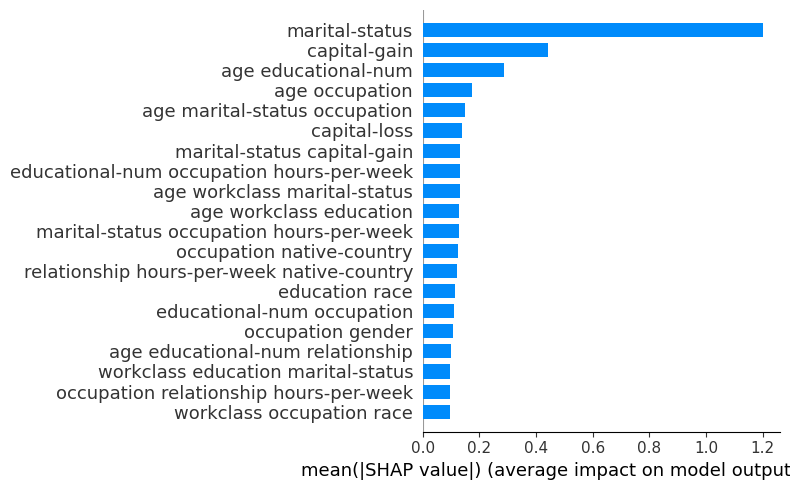

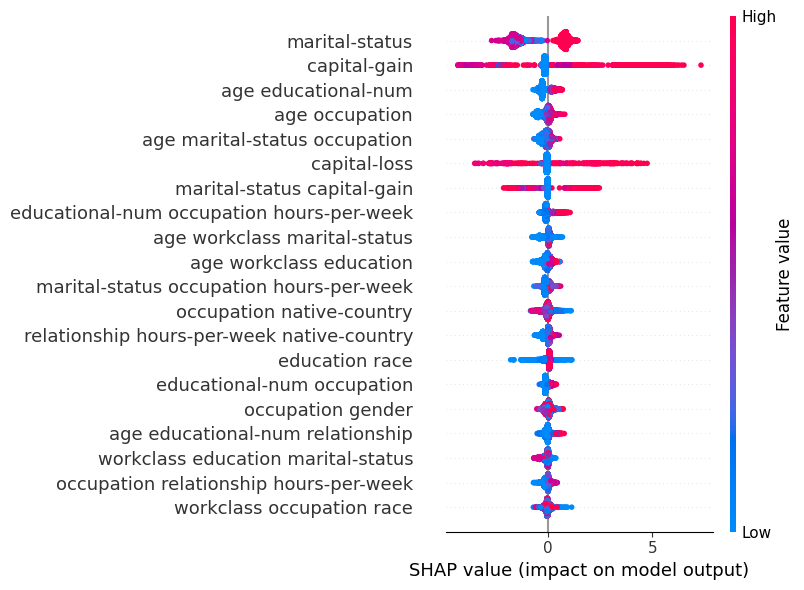

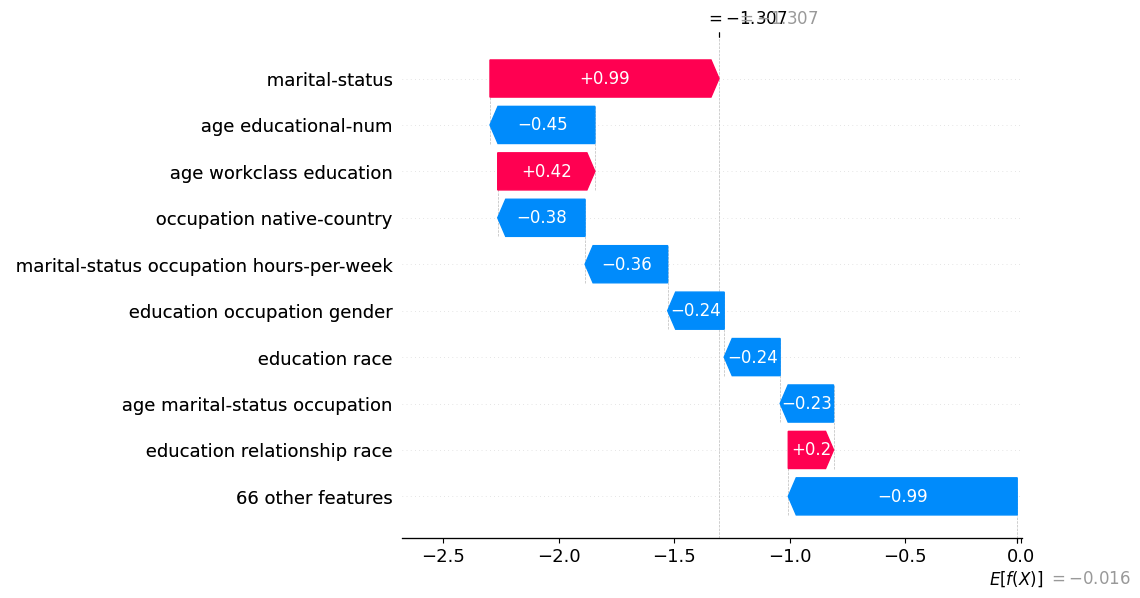

In [58]:
# --- SHAP on reduced XGBoost model (top 75 features) ---

import shap

# Create explainer
explainer_xgb_75 = shap.TreeExplainer(xgb_baseline_xgb_75)

# Compute SHAP values on test set
shap_values_xgb_75 = explainer_xgb_75.shap_values(X_test_xgb_75)

# 1. Global feature importance (bar plot)
shap.summary_plot(
    shap_values_xgb_75,
    X_test_xgb_75,
    plot_type="bar",
    plot_size=(8, 5)
)

# 2. Global direction + spread (beeswarm plot)
shap.summary_plot(
    shap_values_xgb_75,
    X_test_xgb_75,
    plot_size=(8, 6)
)

# 3. Single observation explanation
shap.plots._waterfall.waterfall_legacy(
    explainer_xgb_75.expected_value,
    shap_values_xgb_75[0],
    X_test_xgb_75.iloc[0]
)

MetaLearner using OOF predictions

In [59]:
# OOF Stacking Example (RF + XGB → Logistic Regression)
# standalone code cell for reuse as desired

import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

# base models
rf = RandomForestClassifier(class_weight="balanced", random_state=42)
xgb = XGBClassifier(scale_pos_weight=spw, eval_metric="logloss", random_state=42)

# meta model
meta_model = LogisticRegression()

# OOF setup
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# store OOF predictions
rf_oof = np.zeros(len(X_train_fe))
xgb_oof = np.zeros(len(X_train_fe))

# --- Generate OOF predictions ---
for train_idx, val_idx in skf.split(X_train_fe, y_train):
    X_tr, X_val = X_train_fe.iloc[train_idx], X_train_fe.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    
    # train base models on fold
    rf.fit(X_tr, y_tr)
    xgb.fit(X_tr, y_tr)
    
    # predict validation fold (probabilities for class 1)
    rf_oof[val_idx] = rf.predict_proba(X_val)[:, 1]
    xgb_oof[val_idx] = xgb.predict_proba(X_val)[:, 1]

# --- Train meta model on OOF predictions ---
X_meta_train = np.column_stack((rf_oof, xgb_oof))
meta_model.fit(X_meta_train, y_train)

# --- Retrain base models on FULL training data ---
rf.fit(X_train_fe, y_train)
xgb.fit(X_train_fe, y_train)

# --- Generate test predictions ---
rf_test = rf.predict_proba(X_test_fe)[:, 1]
xgb_test = xgb.predict_proba(X_test_fe)[:, 1]

# --- Meta model final predictions ---
X_meta_test = np.column_stack((rf_test, xgb_test))
meta_preds = meta_model.predict(X_meta_test)

# --- Evaluate ---
print("Stacked Model Balanced Accuracy:",
      balanced_accuracy_score(y_test, meta_preds))

Stacked Model Balanced Accuracy: 0.8169878594503708


In [60]:
# comparing balanced accuracy scores across adult_fe data
print("Random Forest adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, rf_preds_fe))
print("XGBoost adult_fe Test Balanced Accuracy:", balanced_accuracy_score(y_test, xgb_preds_fe))    
print("Stacked Model Test Balanced Accuracy:", balanced_accuracy_score(y_test, meta_preds))

Random Forest adult_fe Test Balanced Accuracy: 0.8028377756281657
XGBoost adult_fe Test Balanced Accuracy: 0.8407010306050337
Stacked Model Test Balanced Accuracy: 0.8169878594503708


In [62]:
# Graveyard
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# importing the data
adult = pd.read_csv("/Users/diyapatel/Documents/GitHub/Advanced-ML/Homwork-3/In Class Activities/adult.csv")

# 1. Clean Data Values (Crucial for the Adult dataset)
# This removes leading/trailing spaces from the entries themselves
adult = adult.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# 2. Encoding the Target Variable
adult["income"] = adult["income"].apply(lambda x: 1 if x == ">50K" else 0)

# 3. Separate Features and Target
X = adult.drop('income', axis=1)
y = adult['income']

numeric_features = ['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']

# 4. Preprocessing Pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# 5. Build the Full Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(LogisticRegression(penalty='l1', solver='liblinear', random_state=42))),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 6. Stratified Split (Training/Test)
# stratify=y ensures the 25/75 split is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 7. Stratified Cross-Validation
# shuffle=True and stratify ensures no fold is missing a class
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

param_grid = {
    'feature_selection__estimator__C': [0.1, 1.0],
    'classifier__n_estimators': [100]
}



# 8. Run Workflow
grid_search = GridSearchCV(full_pipeline, param_grid, cv=skf, scoring='accuracy')
grid_search.fit(X_train, y_train)

# --- RESULTS ---
print(f"\nBest CV Accuracy: {grid_search.best_score_:.4f}")

# Identifying the "Kept" Features
selector = grid_search.best_estimator_.named_steps['feature_selection']
feature_names = grid_search.best_estimator_.named_steps['preprocessor'].get_feature_names_out()
final_features = feature_names[selector.get_support()]

print(f"Features selected by Lasso: {len(final_features)} out of {len(feature_names)}")



Best CV Accuracy: 0.8548
Features selected by Lasso: 43 out of 108


In [63]:
# --- RESULTS SUMMARY ---

best_pipe = grid_search.best_estimator_

print(f"\nBest CV Accuracy: {grid_search.best_score_:.4f}")

# Extract components
selector = best_pipe.named_steps["feature_selection"]
preprocessor = best_pipe.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()
mask = selector.get_support()
final_features = feature_names[mask]

# --- 1. Encoded Features ---
print(f"\nEncoded features selected by Lasso: {len(final_features)} out of {len(feature_names)}")

print("\nSelected encoded features (first 50 shown):")
for f in final_features[:50]:
    print(f)

# --- 2. Map Back to Original Features ---
selected_original_features = set()

for f in final_features:
    if f.startswith("num__"):
        selected_original_features.add(f.replace("num__", ""))
    elif f.startswith("cat__"):
        remainder = f.replace("cat__", "", 1)
        matched = False
        for col in categorical_features:
            prefix = col + "_"
            if remainder.startswith(prefix):
                selected_original_features.add(col)
                matched = True
                break
        if not matched:
            selected_original_features.add(remainder)

all_original_features = set(numeric_features + categorical_features)

# --- 3. Clean Output for Engineering ---
print("\n\n=== ORIGINAL FEATURES KEPT ===")
for f in sorted(selected_original_features):
    print(f)

print(f"\nKept {len(selected_original_features)} out of {len(all_original_features)} original features")

# --- 4. What Was Removed ---
removed_original_features = all_original_features - selected_original_features

print("\n=== ORIGINAL FEATURES REMOVED ===")
for f in sorted(removed_original_features):
    print(f)

# --- 5. Grouped Summary (VERY useful) ---
from collections import defaultdict

grouped = defaultdict(int)

for f in final_features:
    if f.startswith("num__"):
        grouped[f.replace("num__", "")] += 1
    elif f.startswith("cat__"):
        remainder = f.replace("cat__", "", 1)
        for col in categorical_features:
            if remainder.startswith(col + "_"):
                grouped[col] += 1
                break

print("\n=== FEATURE USAGE SUMMARY ===")
for k in sorted(grouped):
    print(f"{k}: {grouped[k]} encoded features selected")


Best CV Accuracy: 0.8548

Encoded features selected by Lasso: 43 out of 108

Selected encoded features (first 50 shown):
num__age
num__fnlwgt
num__educational-num
num__capital-gain
num__capital-loss
num__hours-per-week
cat__workclass_Federal-gov
cat__workclass_Local-gov
cat__workclass_Private
cat__workclass_Self-emp-inc
cat__workclass_Self-emp-not-inc
cat__workclass_State-gov
cat__education_11th
cat__education_Assoc-acdm
cat__education_Assoc-voc
cat__education_HS-grad
cat__education_Prof-school
cat__education_Some-college
cat__marital-status_Divorced
cat__marital-status_Married-civ-spouse
cat__marital-status_Never-married
cat__occupation_?
cat__occupation_Exec-managerial
cat__occupation_Farming-fishing
cat__occupation_Handlers-cleaners
cat__occupation_Machine-op-inspct
cat__occupation_Other-service
cat__occupation_Prof-specialty
cat__occupation_Protective-serv
cat__occupation_Sales
cat__occupation_Tech-support
cat__occupation_Transport-moving
cat__relationship_Other-relative
cat__rela

### Final Evaluation & Reflection

### Performance Changes with Feature Reduction:
Initially, using the base engineered features (adult_fe), Random Forest had a balanced accuracy of ~80.28% and XGBoost reached ~84.07%. When I generated all 377 polynomial features (adult_poly), performance actually dropped slightly (RF to 79.9%, XGB to 83.46%). However, after averaging feature importance and permutation importance to reduce the dataset to just the top 75 features, Random Forest's accuracy rebounded to ~80.32%. This showed that while a few interactions were helpful, throwing everything in was adding too much noise.

### Consistently Important Features:
Across both models and importance ranking methods, core features like capital-gain, marital-status, educational-num, and age were consistently at the top. For the polynomial features, interactions involving these core attributes—such as marital-status native-country and age marital-status occupation—proved to be the most impactful.

### Features Removed and Why:
I removed over 300 of the automatically generated polynomial features. I did this because their permutation importance was near zero (or even negative), meaning they weren't actually helping the model make better decisions on unseen data. By cutting them out and keeping only the top 75, we reduced dimensionality, sped up training, and removed noise that was causing the models to slightly overfit.

### Did Stacking Improve Performance?
Stacking (using a Logistic Regression meta-learner on out-of-fold predictions) gave a test balanced accuracy of ~81.70%. This improved upon the standalone Random Forest, but it failed to beat the standalone XGBoost (84.07%). In this case, stacking didn't improve our overall best performance, likely because the XGBoost model was already so dominant that blending it with the weaker Random Forest model just diluted its predictions.

### What I Learned About Model Behavior:
Through the SHAP analysis and importance rankings, I learned that my models rely heavily on just a handful of demographic and financial indicators (like capital gain and marital status) to make splits. I also learned a valuable lesson about feature engineering: "more" isn't always "better." Adding polynomial interactions hurt the models until I systematically filtered out the useless ones, proving that feature selection is just as important as feature generation!